In [1]:
%load_ext autoreload
%autoreload 2

from data_pipeline import *
import torch_geometric.transforms as T

from training_tools.splitter import StratifiedSplitterWithTestHoldout, HoldoutMode
from training_tools.task import TaskBinaryNodeClassification
from training_tools.trainer import Trainer
from training_tools.validation import CrossValidator
from training_tools.evaluation import Evaluator

from models import GCN, GCN_Sage, MLP

from tqdm import tqdm


pre_transform = T.Compose([
    MarkCommonNodes(edge_types=('AD','PD')),
    ReindexConsecutive(),
    MergeRelationsToHomogeneous(merge=['AD','PD'], edge_attr_reduce='sum'),
    FilterSmallConnectedComponents(topk=1)
])

ds = NeuroDegAnc2VecDataset(root='data', pre_transform=pre_transform, force_reload=True)
data = ds[0]

/home/emanuele/Documents/Tesi/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing...
Done!


In [2]:
data

Data(x=[153, 200], edge_index=[2, 647], y=[153], edge_attr=[647, 1], is_common=[153], string_id=[153])

In [2]:
# 0: AD , 1: PD
import networkx as nx

ei = data.edge_index.detach().cpu()
N = len(data.y)

edges = set()
for u, v in ei.t().tolist():
    if u == v:
        continue  # opzionale: ignora self-loop
    a, b = (u, v) if u < v else (v, u)
    edges.add((a, b))

G = nx.Graph()
G.add_nodes_from(range(N))
G.add_edges_from(edges)

# aggiungi label come attributo nodo (opzionale ma comodo)
labels = data.y.detach().cpu().tolist()
nx.set_node_attributes(G, {i: int(labels[i]) for i in range(N)}, "y")

# 2) Nodi per classe con i "2" che contano in entrambe
nodes_class0 = {i for i, lab in enumerate(labels) if lab in (0, 2)}
nodes_class1 = {i for i, lab in enumerate(labels) if lab in (1, 2)}

n0 = len(nodes_class0)
n1 = len(nodes_class1)

# 3) Archi per classe = archi interni al sottografo indotto dai nodi della classe
#    (ogni arco viene contato al più una volta per classe; può contare in entrambe se collega due nodi "2")
E0 = sum(1 for u, v in G.edges() if (u in nodes_class0 and v in nodes_class0))
E1 = sum(1 for u, v in G.edges() if (u in nodes_class1 and v in nodes_class1))

print(f"AD: nodi {n0}, archi {E0}")
print(f"PD: nodi {n1}, archi {E1}")


AD: nodi 80, archi 142
PD: nodi 85, archi 519


In [3]:
def compare_models_over_repeats(
    data,                   # Data
    model_factories,           # [factory_A, factory_B, ...]
    splitter_ctor,             # lambda seed, mode: StratifiedNestedSplitter(...)
    task, trainer, mode="transductive",
    n = 10
):
    seeds=list(range(n, 2*n))
    # metriche per modello: dict[name] -> list of per-run test F1
    results = {i: [] for i in range(len(model_factories))}
    artifacts_list = []

    with tqdm(total=len(seeds), desc="Training Progress", unit="iteration") as pbar:
        for seed in seeds:
            splitter = splitter_ctor(seed, mode)
            parts = splitter.split(data, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)

            for idx, factory in enumerate(model_factories):
                cv = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
                artifacts, summary = cv.run(task, data, parts)

                evaluator = Evaluator(model_factory=factory, mode=mode)
                test_metrics = evaluator.evaluate(task, data, parts, artifacts["best_state"])
                results[idx].append(test_metrics["f1"])  # metrica primaria
                artifacts_list.append(artifacts)
            pbar.update(1)

    return results, artifacts_list

model_factories = [
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=2, dropout=0),
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=2, dropout=0, head_type="mlp"),
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=2, dropout=0.2),
    lambda : GCN(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0),
    lambda : MLP(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)
]

splitter_ctor = lambda seed, mode: StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed, mode=mode)

task    = TaskBinaryNodeClassification(threshold=0.5, pos_weight=None)
trainer = Trainer(lr=1e-3, weight_decay=5e-4, max_epochs=50, patience=5)

results = dict()

# results['transductive'], artifacts_list = compare_models_over_repeats(data, model_factories, splitter_ctor, task, trainer, mode='transductive', n=200)

In [7]:
model_names = ["Sage2L", "Sage2L+MLP", "Sage2L+drop", "GCN", "MLP"]

len(artifacts_list)
model_artifacts = {
    "Sage2L" : artifacts_list[:50],
    "Sage2L+MLP" : artifacts_list[50:100],
    "Sage2L+drop" : artifacts_list[100:150],
    "GCN" : artifacts_list[150:200],
    "MLP" : artifacts_list[200:]
}
import random

random_training_per_model = {model : random.choice(artifacts_list) for model, artifacts_list in model_artifacts.items()}

random_training_per_model['Sage2L']

NameError: name 'artifacts_list' is not defined

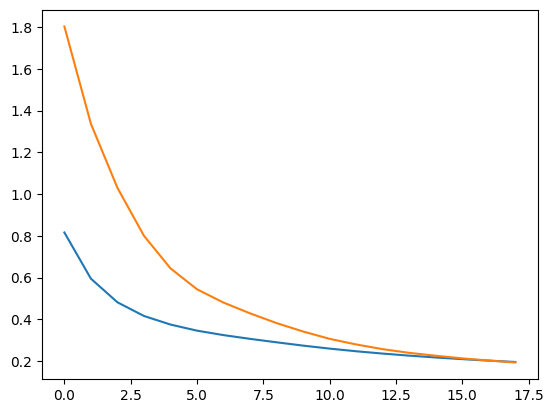

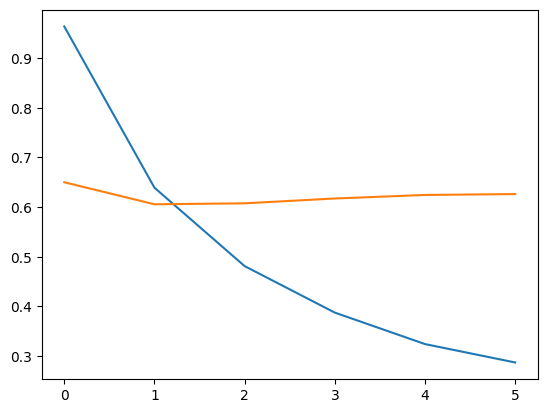

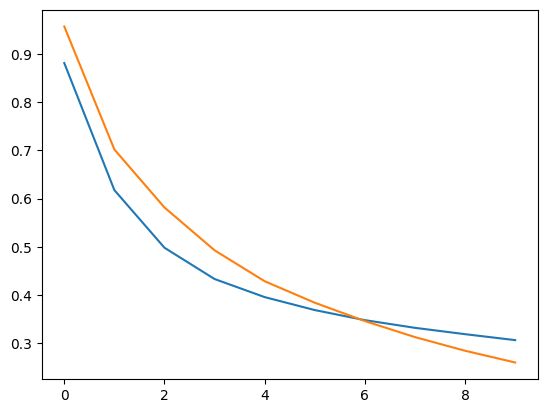

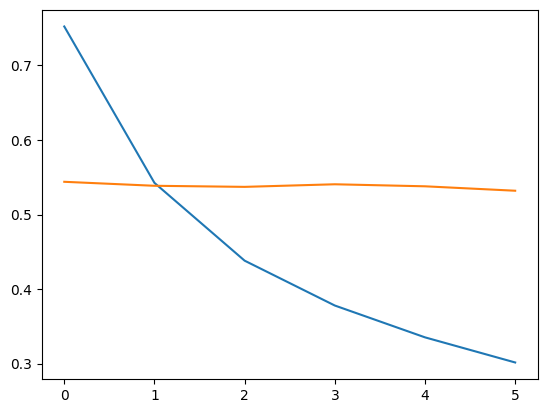

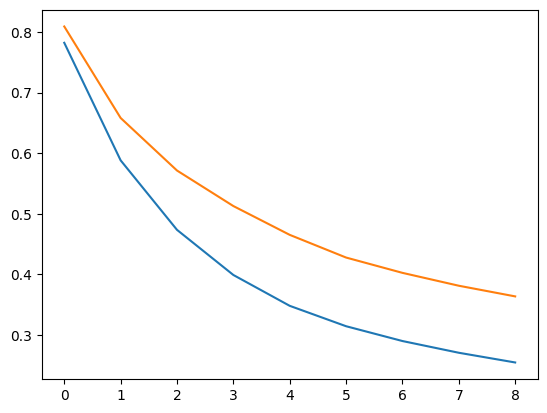

In [ ]:
for fold in random_training_per_model['GCN']['per_fold']:
    train_art = [art['loss'] for art in fold['history']['train']]
    val_art = [art['loss'] for art in fold['history']['val']]

    x_train = [x for x in range(len(train_art))]
    x_val = [x for x in range(len(val_art))]

    import matplotlib.pyplot as plt

    plt.plot(x_train, train_art)
    plt.plot(x_val, val_art)
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# model_names = [model().__class__.__name__ for model in model_factories]
model_names = ["Sage2L", "Sage2L+MLP", "Sage2L+drop", "GCN", "MLP"]

# formatted_transductive  = dict(zip(model_names, [np.array(res).mean() for _, res in results['transductive'].items()]))

def plot_f1(formatted, title, subset=set()):
    if subset:
        formatted = {k:formatted[k] for k in subset}

    sorted_formatted = dict(sorted(formatted.items(), key=lambda x: x[1], reverse=True))

    names = list(sorted_formatted.keys())
    values = list(sorted_formatted.values())

    plt.figure(figsize=(7, 5))
    plt.bar(names, values)
    plt.title(title)
    plt.ylabel("F1 Score")
    plt.xlabel("Modello")
    plt.ylim(0, 1)  # opzionale

    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

    plt.show()

# plot_f1(formatted_transductive  , title='Trasductive F1-scores')
# plot_f1(formatted_transductive , title='Transductive F1-scores', subset=set(['GCN', 'MLP', 'Sage2L']))


import pandas as pd
import seaborn as sns

def plot_f1_boxplot(metrics_dict, title, rotation=0):
    # 1. Convertiamo il dizionario in un DataFrame "Tidy"
    df_list = []
    for label, values in metrics_dict.items():
        arr = np.asarray(values).ravel()
        arr = arr[~np.isnan(arr)]
        temp_df = pd.DataFrame({'Model': label, 'F1 Score': arr})
        df_list.append(temp_df)
    
    df = pd.concat(df_list, ignore_index=True)

    # 2. Calcoliamo l'ordine basato sulla mediana decrescente
    my_order = df.groupby("Model")["F1 Score"].median().sort_values(ascending=False).index

    # 3. Setup estetico di Seaborn
    sns.set_theme(style="whitegrid") # Aggiunge la griglia orizzontale tipica dei paper
    plt.figure(figsize=(8, 6))

    # 4. Creazione del Boxplot
    # 'palette="viridis"' o 'palette="muted"' sono ottimi per la stampa
    ax = sns.boxplot(
        data=df, 
        x='Model', 
        y='F1 Score', 
        order=my_order,
        palette="Blues_d", # Crea una sfumatura professionale
        showmeans=True,
        meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
    )

    # 5. Aggiunta facoltativa di Stripplot (per mostrare i singoli punti/run sopra i box)
    # Rende il grafico molto più onesto e dettagliato
    # sns.stripplot(data=df, x='Modello', y='F1 Score', order=my_order, color="black", alpha=0.3, jitter=True)

    # 6. Annotazione delle mediane
    # In Seaborn, gli indici x partono da 0
    medians = df.groupby("Modello")["F1 Score"].median().reindex(my_order).values
    for i, med in enumerate(medians):
        ax.text(i, min(med + 0.02, 0.98), f"med={med:.3f}", 
                ha="center", va="bottom", color='black', fontsize=10)

    # Finalizzazione
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylim(0, 1.05) # Un po' di margine sopra per l'etichetta
    
    if rotation:
        plt.xticks(rotation=rotation, ha='right')

    sns.despine() # Rimuove i bordi superiore e destro per un look più pulito
    plt.tight_layout()
    plt.show()

In [28]:
sns.color_palette()

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [5]:
from graph_data_manipulation import rewire_degree_preserving_complete, rewire_degree_preserving_stratified_connected, rewire_non_degree_preserving_stratified_complete

mode = 'transductive'
seed = 42
gcn_factory = lambda : GCN(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)
mlp_factory = lambda : MLP(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)
splitter_ctor = lambda seed, mode: StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed, mode=mode)


task    = TaskBinaryNodeClassification(threshold=0.5, pos_weight=None)
trainer = Trainer(lr=1e-3, weight_decay=5e-4, max_epochs=50, patience=10)

n = 10  # Numero di training
m = 20  # Numero di rewiring

rewiring_algs = {
    "R1": rewire_degree_preserving_complete,
    "R2": rewire_degree_preserving_stratified_connected,
    "R3": rewire_non_degree_preserving_stratified_complete
}

for name, alg in rewiring_algs.items():
    print(f"{name} | {alg.__name__}")

training_metrics = dict() # key: `model's name`; value: List[artifact]

# --- Training MLP
test_metrics_mlp, artifacts_mlp = compare_models_over_repeats(
    data, 
    [mlp_factory], 
    splitter_ctor, task, trainer, mode='transductive', n=n)

training_metrics['MLP'] = test_metrics_mlp[0]

# --- Training GCN
test_metrics_gcn = []
gcn_artifacts = list()
for x in tqdm(range(n*m), desc="GCN training", unit="trainings"): 
    splitter = StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed + x, mode=mode)
    parts = splitter.split(data, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)

    cv = CrossValidator(trainer=trainer, model_factory=gcn_factory, mode=mode, select_by="f1")
    artifacts, summary = cv.run(task, data, parts)

    gcn_artifacts.append(artifacts)

    evaluator = Evaluator(model_factory=gcn_factory, mode=mode)
    test_metrics_gcn.append(evaluator.evaluate(task, data, parts, artifacts["best_state"])['f1'])

training_metrics['GCN'] = test_metrics_gcn

# --- Training GCN on rewiring
progress_bar = tqdm(total=n*m*len(rewiring_algs), unit="trainings")
test_metrics_rew = dict()
for alg_name in rewiring_algs.keys():
    test_metrics_rew[alg_name] = list()

rew_count = 0
for alg_name, rew_alg in rewiring_algs.items():
    rew_count += 1
    rew_artifacts_list = list()
    for i in range(m):
        progress_bar.set_description(f"[{rew_count}] [{alg_name}] Training on {i+1}th rewiring")
        g_rewired = rew_alg(
            data,
            seed=seed + i
        )

        #for x in tqdm.tqdm(range(n), desc="Training GCN on original and rewired graphs", unit="trainings"):
        for j in range(n):
            splitter = StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed + j, mode=mode)
            rewired_parts = splitter.split(g_rewired, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)

            cv_rew = CrossValidator(trainer=trainer, model_factory=gcn_factory, mode=mode, select_by="f1")
            artifacts_rew, summary_rew = cv_rew.run(task, g_rewired, rewired_parts)

            rew_artifacts_list.append(artifacts_rew)

            evaluator = Evaluator(model_factory=gcn_factory, mode=mode)
            test_metrics_rew[alg_name].append(evaluator.evaluate(task, g_rewired, rewired_parts, artifacts_rew["best_state"])['f1'])

            progress_bar.update(1)
        
        progress_bar.update(1)

training_metrics = {**training_metrics, **test_metrics_rew}

import json
with open('scores.json', 'w', encoding='utf-8') as f:
    json.dump(training_metrics, f, indent=4)

R1 | rewire_degree_preserving_complete
R2 | rewire_degree_preserving_stratified_connected
R3 | rewire_non_degree_preserving_stratified_complete


[1] [R1] Training on 4th rewiring:   7%|▋         | 42/600 [00:34<07:33,  1.23trainings/s]

KeyboardInterrupt: 

In [32]:
import json

with open('scores.json', 'r', encoding='utf-8') as f:
    out = json.load(f)

# report Inter Quartile Range
for k, v in out.items():
    mean_val = np.mean(v)
    q1 = np.percentile(v, 25)
    q3 = np.percentile(v, 75)
    iqr = q3-q1
    print(f"{k}: {mean_val:.3f} ± [{q1:.3f}, {q3:.3f}] (IQR: {iqr:.3f})")

plot_f1_boxplot(out, "Graph topology boxplot")



MLP: 0.739 ± [0.617, 0.825] (IQR: 0.208)
GCN: 0.882 ± [0.833, 0.933] (IQR: 0.100)
R1: 0.649 ± [0.600, 0.700] (IQR: 0.100)
R2: 0.879 ± [0.833, 0.933] (IQR: 0.100)
R3: 0.954 ± [0.931, 1.000] (IQR: 0.069)


ValueError: Could not interpret value `Model` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

[0.9230769230769231, 0.9333333333333333, 1.0, 0.7692307692307693, 0.8571428571428571, 1.0, 0.9230769230769231, 0.6666666666666666, 0.9333333333333333, 0.75, 0.8333333333333334, 0.9333333333333333, 0.4444444444444444, 0.8571428571428571, 0.8333333333333334, 1.0, 0.9333333333333333, 1.0, 1.0, 0.9230769230769231, 1.0, 0.9230769230769231, 0.8571428571428571, 0.8571428571428571, 0.9333333333333333, 1.0, 0.875, 0.6, 0.9333333333333333, 1.0, 1.0, 1.0, 0.9333333333333333, 0.9230769230769231, 0.9333333333333333, 0.7692307692307693, 0.8571428571428571, 0.9333333333333333, 0.9230769230769231, 1.0, 1.0, 0.9333333333333333, 0.875, 0.9333333333333333, 0.8571428571428571, 0.8333333333333334, 0.8235294117647058, 0.9333333333333333, 0.7272727272727273, 0.7272727272727273, 0.9333333333333333, 0.4444444444444444, 0.8571428571428571, 0.7692307692307693, 0.9333333333333333, 0.8333333333333334, 1.0, 0.9333333333333333, 0.9230769230769231, 0.6666666666666666, 0.8571428571428571, 1.0, 1.0, 0.75, 0.83333333333

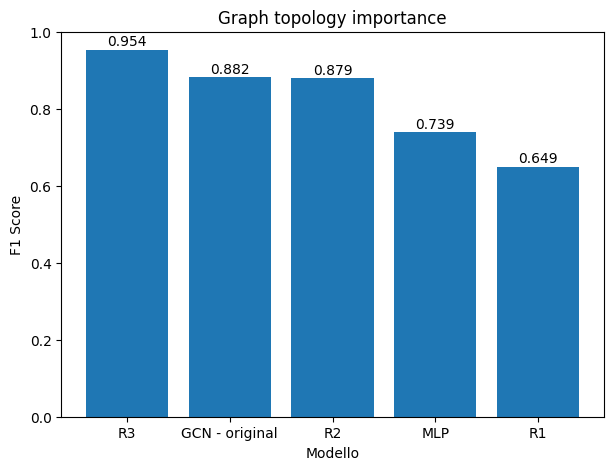

/tmp/ipykernel_9154/1829825182.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


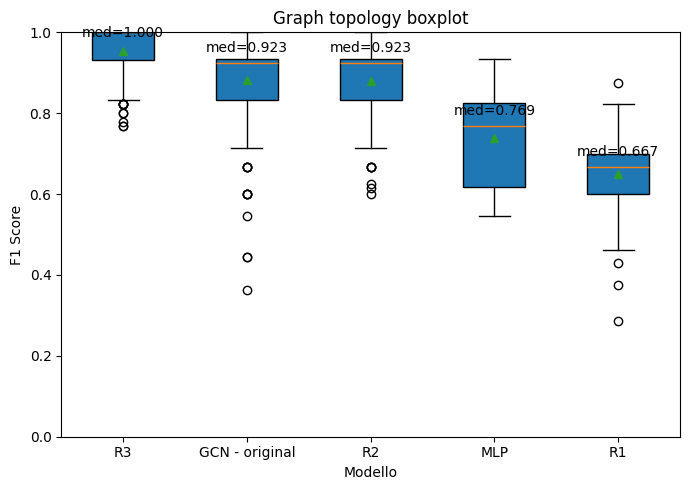

In [20]:
formatted = dict()
formatted['GCN - original'] = np.array(test_metrics_gcn)
for alg_name, metrics in test_metrics_rew.items():
    formatted[alg_name] = np.array(metrics)

print(test_metrics_gcn)
print(test_metrics_mlp)
formatted['MLP'] = np.array(list(test_metrics_mlp[0]))

formatted_mean = {k:v.mean() for k,v in formatted.items()}

plot_f1(formatted_mean, title='Graph topology importance')
plot_f1_boxplot(formatted, title="Graph topology boxplot")

In [22]:
for model_name, performance_list in training_metrics.items():
    performance_np = np.array(performance_list)
    print(f'{model_name}\t| {performance_np.mean():.3f}\t|{performance_np.std():.3f}')

len(training_metrics['GCN'])

MLP	| 0.739	|0.136
GCN	| 0.882	|0.112
R1	| 0.649	|0.089
R2	| 0.879	|0.094
R3	| 0.954	|0.058


200

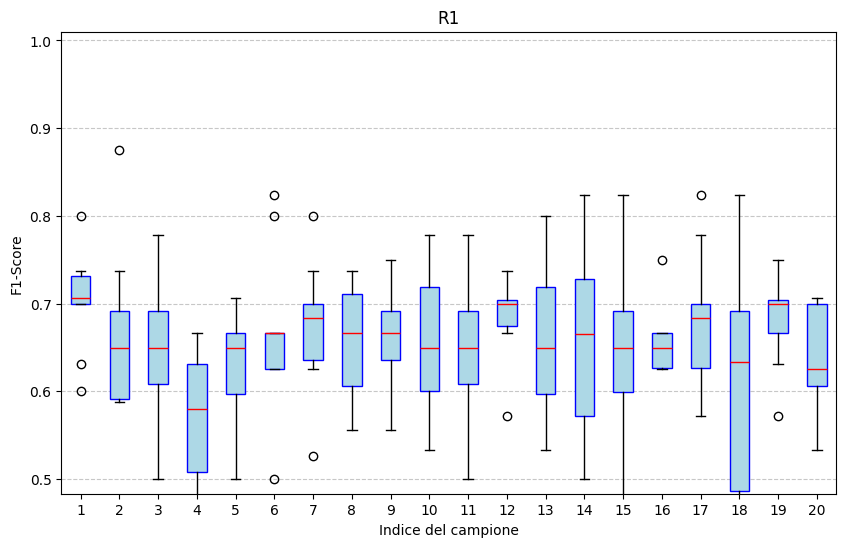

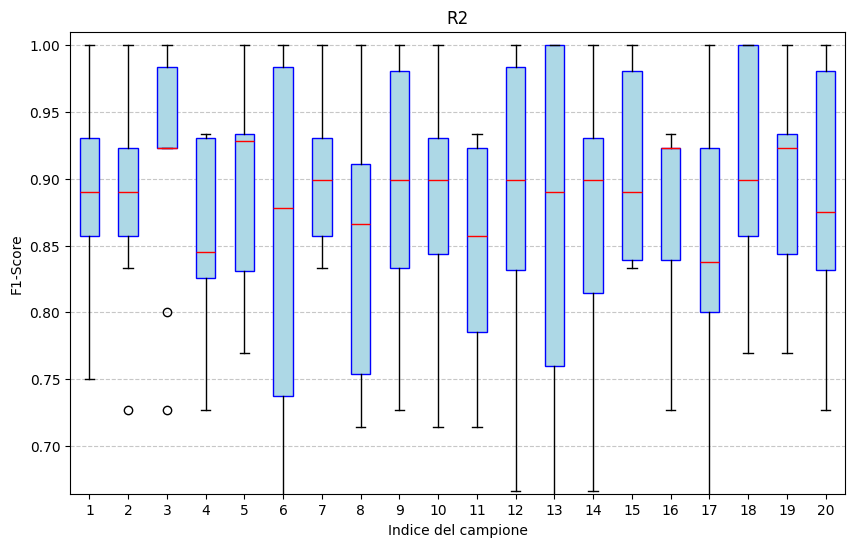

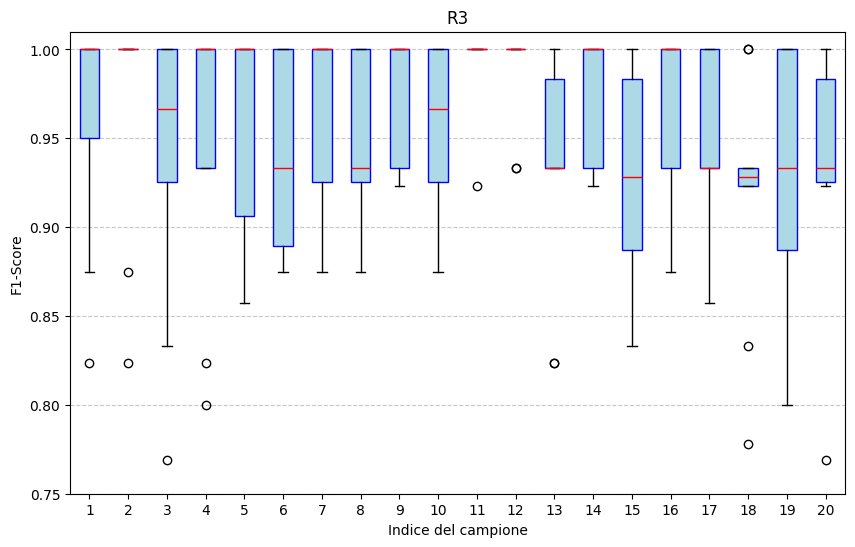

In [23]:
# Sebbene non abbia esplicitamente registrato le prestazioni per ogni M, uso 'append', quindi sono ordinate
# Dividendo in M blocchi ottengo le prestazioni su un singolo rewiring


def plot_boxes(training_blocks, title, jitter=True):
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(10, 6))

    # Creazione del boxplot
    plt.boxplot(training_blocks, patch_artist=True, 
                boxprops=dict(facecolor="lightblue", color="blue"),
                medianprops=dict(color="red"))

    plt.title(title)
    plt.ylabel("F1-Score")
    plt.xlabel("Indice del campione")
    min_val = float(min(min(*training_blocks)))
    plt.ylim(min_val - 0.05, 1.01) # Limite superiore leggermente sopra 1 per visibilità
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    if jitter:
        for i, d in enumerate(training_blocks, start=1):
            y = d
            x = np.random.normal(i, 0.04, size=len(y)) # Aggiunge un piccolo spostamento orizzontale
            plt.plot(x, y, 'g.', alpha=0.5) # Disegna i punti reali in rosso

    plt.show()

for model_name in ['R1', 'R2', 'R3']:
    training_blocks = [training_metrics[model_name][block_i:block_i+10] for block_i in range(0, 201 - 10, 10)]
    plot_boxes(training_blocks, title=model_name, jitter=False)

# Test statistici

### Metodo e motivazioni
È stato utilizzato il test di Kruskal-Wallis per il confronto di distribuzioni non parametrico, che permette di evitare assunzioni sulla distribuzione. Questo metodo lavora su gruppi di distribuzioni e dice se ce n'è almeno una sensibilmente diversa dalle altre.
L'output è sostanzialmente un P-Value fatto sulle seguenti ipotesi:
- $H_0$: Le distribuzioni non sono statisticamente differenti
- $H_1$: Almeno una delle distribuzioni è statisticamente differente

Questo test di fa confrontando le mediane: mediane uguali vuol dire distribuzioni probebilmente uguali.
Con $p < 0.05$ si rifiuta l'ipotesi nulla.

Se il test ha successo si fa analisi post-hoc con il test di Dunn, una variante a coppie con lo stesso funzionamento. Su questa viene fatta la **correzione di Bonferroni**, ovvero viene diviso il threashold $p$ per il numero di confronti (6 in questo caso).
Il test di Dunn viene scelto come post-hoc perché utilizza le stesse statistiche di Kruskal-Wallis, mantenendo coerenza nel metodo.

### Formalità e definizioni
##### Test di Kruskal-Wallis
In quanto test non parametrici viene fatto prima un passo di *ranking*: i valori su cui si sta facendo testing sono ordinati, al valore più piccolo viene dato rango 1, il secondo valore più piccolo rango 2, ecc...

Questo viene fatto per ogni gruppo. La statistica $H$ di Kruskal-Wallis misura quanto la somma dei ranghi di ciascun gruppo devia dalla somma dei ranghi attesa sotto $H_0$, calcolato come:
$$
H = \frac{12}{N(N+1)} \sum_{i=1}^k \frac{R_i^2}{n_i} -3(N+1)
$$​
Dove $R_i$ è la somma dei ranghi dell'$i$-esimo gruppo, $n_i$ è la numerosità del gruppo $i$-esimo, $k$ è il numero di gruppi ed $N$ è il numero totale dei campioni.

Da questo valore si calcola spesso una correzione in base ai "pareggi" dei ranghi.

Infine, sotto ipotesi nulla $H$ segue asintoticamente $\chi^2$ con $k-1$ gradi di libertà. Da questa osservazione si calcola il p-value come:
$$
P(\chi^2 > H)
$$

Intuitivamente, visto che la distribuzione Chi-Quadro ha delle code pesanti, per un $H$ grande è improbabile che una variabile casuale assuma un valore in quel punto.

##### Test di Dunn
Per ogni coppia di valori $(i, j)$ si calcolano le distanze tra le medie dei gruppi $d_{ij} = \vert \overline R_i - \overline R_j\vert$ e si definisce la statistica: $$Z = \frac{\overline R_i - \overline R_j}{\sigma_{ij}}$$
Con $\sigma_{ij}$ errore standard della differenza delle medie.

Sotto ipotesi nulla, $Z$ segue asintoticamente $\mathcal{N}(0,1)$. È possobile calcolare il p-value come segue:
$$P = 2 \cdot [1 - \Phi(\vert Z_{ij} \vert )]$$
Con $\Phi$ funzione di ripartizione della normale standard.

##### Correzione di Bonferroni
Quando il numero di confronti aumenta, la probabilità di ottenere un errore di tipo $I$ aumenta. Si può dividere la soglia del p-value per il numero di confronti per correggere questo bias. Nel codice sottostante si fa l'inverso, moltiplicando i p-value calcolati per il numero di confronti.

##### Effect Size
È un coefficiente che indica quanto la differenza di distribuzione sia marcata. In questo contesto è calcolato come lo Z-score normalizzato con la radice del numero di osservazioni (in questo caso 20):
$$r = \frac{Z}{\sqrt N}$$

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt
import json

with open('./training_output/scores_AD-PD_transductive.json', 'r', encoding='utf-8') as f:
    scores = json.load(f)
    data = {
        'Standard': scores['GCN'],
        'R1': scores['R1'],
        'R2': scores['R2'],
        'R3': scores['R3']
    }

df = pd.DataFrame(data)
df_melted = df.melt(var_name='Condition', value_name='F1_Score')

# Test di Kruskal-Wallis (non parametrico)
h_stat, p_kruskal = stats.kruskal(data['Standard'], data['R1'], data['R2'], data['R3'])

print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"p-value: {p_kruskal:.5e}")

# Analisi Post-hoc - Test di Dunn + correzione di Bonferroni
if p_kruskal < 0.05:
    print("\nDifferenza significativa rilevata")
else:
    print("\nNessuna differenza significativa tra i gruppi.")

# Calcolo dell'Effect Size (ϵ^2)
def calculate_epsilon_squared(h_stat, n):
    """Calcola l'Epsilon-quadrato per Kruskal-Wallis."""
    return h_stat / ((n**2 - 1) / (n + 1))

n_total = len(df_melted)
epsilon_sq = calculate_epsilon_squared(h_stat, n_total)

print(f"Epsilon-squared: {epsilon_sq:.4f}")

# Interpretazione automatica
if epsilon_sq >= 0.26:
    effect = "Large"
elif epsilon_sq >= 0.08:
    effect = "Medium"
else:
    effect = "Small"
print(f"L'entità dell'effetto è: {effect}")

Kruskal-Wallis H-statistic: 466.1083
p-value: 1.05434e-100

Differenza significativa rilevata
Epsilon-squared: 0.5834
L'entità dell'effetto è: Large


In [4]:
if p_kruskal < 0.05:
    print("Eseguendo il test di Dunn...")
    posthoc = sp.posthoc_dunn(df_melted, val_col='F1_Score', group_col='Condition', p_adjust='bonferroni')
    print(posthoc)
else:
    print(f"No posthoc - {p_kruskal:.3f}")

import pandas as pd
import numpy as np
from scipy import stats

ranks = stats.rankdata(df_melted['F1_Score'])
df_melted['Ranks'] = ranks

def get_dunn_z(group1, group2, df, val_col='F1_Score'):
    """ Calcola lo Z-score di Dunn con correzione per i legami (ties) """
    r1 = df[df['Condition'] == group1]['Ranks']
    r2 = df[df['Condition'] == group2]['Ranks']
    
    n1, n2 = len(r1), len(r2)
    N = len(df)
    
    # 1. Differenza medie dei ranghi
    mean_diff = np.abs(r1.mean() - r2.mean())
    
    # 2. Calcolo della somma dei legami (Ties)
    counts = df[val_col].value_counts().values
    tie_sum = np.sum(counts**3 - counts)
    
    # 3. Errore standard corretto per i legami (Dunn, 1964)
    variance_rank = (N * (N + 1) / 12.0) - (tie_sum / (12.0 * (N - 1)))
    se = np.sqrt(variance_rank * (1.0 / n1 + 1.0 / n2))
    
    z_score = mean_diff / se
    return z_score

def run_full_statistical_report(df_long):
    """Esegue l'analisi post-hoc di Dunn completa con Effect Size r e Bonferroni."""
    df = df_long.copy()
    N_total = len(df)
    
    # 1. Assegnazione dei ranghi globali
    df['Ranks'] = stats.rankdata(df['F1_Score'])
    
    groups = df['Condition'].unique()
    results = []

    # 2. Ciclo sui confronti a coppie
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1, g2 = groups[i], groups[j]
            
            z_score = get_dunn_z(g1, g2, df)
            
            # CORREZIONE: Effect Size r di Rosenthal r = |Z| / sqrt(N_total)
            r_val = z_score / np.sqrt(N_total)
            
            # Calcolo p-value grezzo (survival function per evitare underflow)
            p_raw = 2 * stats.norm.sf(z_score)
            
            results.append({
                'Comparison': f"{g1} vs {g2}",
                'Z_score': z_score,
                'r_effect': r_val,
                'p_raw': p_raw
            })
            
    # 3. Creazione DataFrame e Correzione di Bonferroni
    report_df = pd.DataFrame(results)
    m = len(report_df)  # Numero di comparazioni totali
    report_df['p_adj'] = report_df['p_raw'].apply(lambda x: min(x * m, 1.0))
    
    # Classificazione dell'Effect Size secondo Cohen
    def categorize_r(r):
        if r < 0.1:
            return 'Negligible'
        elif r < 0.3:
            return 'Small'
        elif r < 0.5:
            return 'Medium'
        else:
            return 'Large'
            
    report_df['Effect_Size_Class'] = report_df['r_effect'].apply(categorize_r)
    
    return report_df

# Esecuzione
stat_df = run_full_statistical_report(df_melted)
print("---\nDettaglio sulle comparazioni")
print(stat_df)

 

Eseguendo il test di Dunn...
                    R1            R2            R3      Standard
R1        1.000000e+00  1.533211e-44  2.116682e-98  5.822527e-38
R2        1.533211e-44  1.000000e+00  1.425065e-11  1.000000e+00
R3        2.116682e-98  1.425065e-11  1.000000e+00  2.780985e-15
Standard  5.822527e-38  1.000000e+00  2.780985e-15  1.000000e+00
---
Dettaglio sulle comparazioni
       Comparison    Z_score  r_effect         p_raw         p_adj  \
0  Standard vs R1  13.017706  0.460245  9.704212e-39  5.822527e-38   
1  Standard vs R2   1.110227  0.039252  2.669014e-01  1.000000e+00   
2  Standard vs R3   8.120701  0.287110  4.634975e-16  2.780985e-15   
3        R1 vs R2  14.127933  0.499498  2.555352e-45  1.533211e-44   
4        R1 vs R3  21.138408  0.747356  3.527803e-99  2.116682e-98   
5        R2 vs R3   7.010475  0.247858  2.375108e-12  1.425065e-11   

  Effect_Size_Class  
0            Medium  
1        Negligible  
2             Small  
3            Medium  
4           

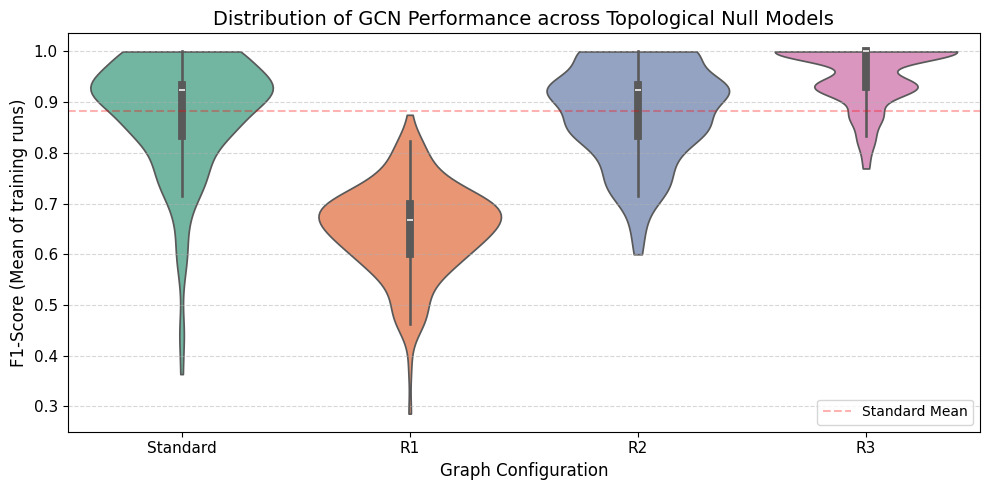

In [5]:
plt.figure(figsize=(10, 5))

# Creazione del Violin Plot
sns.violinplot(
    data=df_melted,
    x='Condition', y='F1_Score',
    hue='Condition', legend=False, 
    palette='Set2', inner='box', cut=0)

# Formattazione
plt.title('Distribution of GCN Performance across Topological Null Models', fontsize=14)
plt.ylabel('F1-Score (Mean of training runs)', fontsize=12)
plt.xlabel('Graph Configuration', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Media GCN baseline
baseline_mean = df['Standard'].mean()
plt.axhline(baseline_mean, color='red', linestyle='--', alpha=0.3, label='Standard Mean')

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

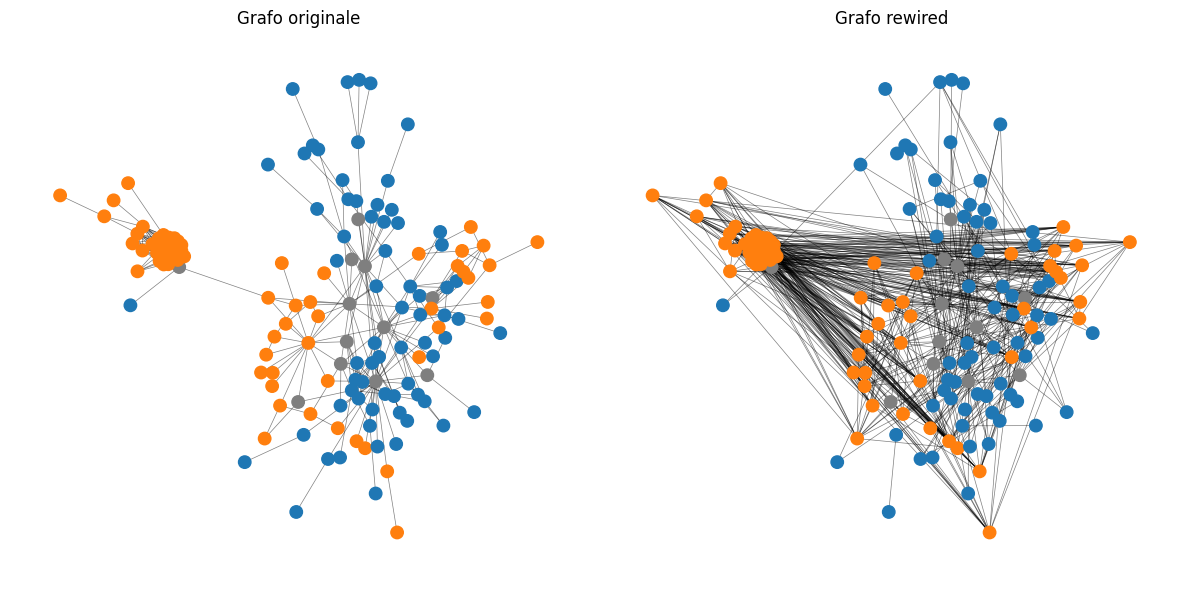

Data(x=[153, 200], edge_index=[2, 647], y=[153], edge_attr=[647, 1], is_common=[153], string_id=[153])
Data(x=[153, 200], edge_index=[2, 647], y=[153], edge_attr=[647, 1], is_common=[153], string_id=[153])


In [3]:
import torch
from networkx import spring_layout, draw_networkx_nodes, draw_networkx_edges
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data

from graph_data_manipulation import rewire_degree_preserving_complete, rewire_degree_preserving_stratified_connected, rewire_non_degree_preserving_stratified_complete

def plot_graph_before_after(
    data: "Data",
    data_rewired: "Data",
    *,
    node_size: int = 80,
    alpha_edges: float = 0.5,
    seed_layout: int = 42,
):
    """
    Plotta il grafo originale e quello rewired affiancati, usando lo stesso layout.

    - Colore nodi = classe (y=0, y=1).
    - Stesso posizionamento (spring layout) per confronto visivo.

    Parametri
    ---------
    data : Data
        Grafo originale PyG.
    data_rewired : Data
        Grafo dopo rewiring (stesso numero di nodi, stessi indici).
    node_size : int
        Dimensione dei nodi nel plot.
    alpha_edges : float
        Trasparenza degli archi.
    seed_layout : int
        Seed per il layout spring di NetworkX (riproducibilità).
    """
    assert data.num_nodes == data_rewired.num_nodes, "I due grafi devono avere lo stesso numero di nodi"

    # converte a NetworkX (non orientato per la visualizzazione)
    G_real = to_networkx(data, to_undirected=True, remove_self_loops=True)
    G_rew  = to_networkx(data_rewired, to_undirected=True, remove_self_loops=True)

    # layout unico per entrambi
    pos = spring_layout(G_real, seed=seed_layout)

    # colori nodi in base a y
    y = data.y.detach().cpu().numpy()
    # mappa semplice: 0 -> blu, 1 -> arancione, altro -> grigio
    def _color(c):
        if c == 0:
            return "tab:blue"
        elif c == 1:
            return "tab:orange"
        else:
            return "tab:gray"

    node_colors = [_color(int(c)) for c in y]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # --- grafo originale ---
    ax = axes[0]
    draw_networkx_nodes(
        G_real, pos,
        node_color=node_colors,
        node_size=node_size,
        ax=ax
    )
    draw_networkx_edges(
        G_real, pos,
        alpha=alpha_edges,
        width=0.5,
        ax=ax
    )
    ax.set_title("Grafo originale")
    ax.axis("off")

    # --- grafo rewired ---
    ax = axes[1]
    draw_networkx_nodes(
        G_rew, pos,
        node_color=node_colors,  # stesse classi, stessi colori
        node_size=node_size,
        ax=ax
    )
    draw_networkx_edges(
        G_rew, pos,
        alpha=alpha_edges,
        width=0.5,
        ax=ax
    )
    ax.set_title("Grafo rewired")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

rewired_graph = rewire_non_degree_preserving_stratified_complete(data)
plot_graph_before_after(data, rewired_graph)

print(data)
print(rewired_graph)